In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import json
from itertools import combinations

In [7]:
models = {
    'Qwen2.5-7B-Instruct': 'qwen7b',
    'Llama-3.2-3B-Instruct': 'llama3b',
    'Llama-3.1-8B-Instruct': 'llama8b',
}
model_names = {v: k for k, v in models.items()}
seeds = ["264759", "4960273", "738294", "4625", "912345"]
metrics = ['rouge-rouge1', 'rouge-rougeL', 'bertscore-precision']
metric_names = {
    'rouge-rouge1': 'ROUGE-1',
    'rouge-rougeL': 'ROUGE-L',
    'bertscore-precision': 'BertScore'
}

In [8]:
all_values = {}
for model, modelshort in models.items():
    all_values[modelshort] = {}
    temp = []
    for seed in seeds:
        with open(f'../summary_semantics/{model}_baseline_{seed}.json') as f:
            data = json.load(f)
        df = []
        for idx, v in data.items():
            row = {"id": idx, 'race': v['race'], 'gender': v['gender']}
            for metric in metrics:
                if metric in v:
                    row[metric] = v[metric]
            df.append(row)
        df = pd.DataFrame(df)
        temp.append(df)
    all_values[modelshort] = temp

In [9]:
def get_values(model, gender, race):
    df = (
        pd.concat(all_values[model])
          .groupby(["id", 'race', 'gender'], as_index=False)
          .mean(numeric_only=True)
    )
    if gender is not None:
        df = df[df['gender'] == gender]
    if race is not None:
        df = df[df['race'] == race]
    values = []
    for idx, row in df.iterrows():
        values.append({metric: row[metric] for metric in metrics})
    return values

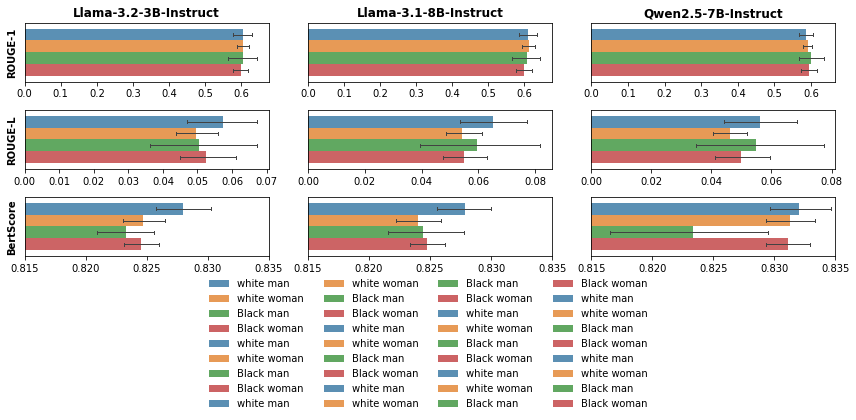

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(12, 4), constrained_layout=True)
for x, metric in enumerate(metrics):
    for y, model in enumerate(['llama3b', 'llama8b', 'qwen7b']):
        series1, series2, series3, series4 = get_values(model, 'man', 'white'), get_values(model, 'woman', 'white'), get_values(model, 'man', 'Black'), get_values(model, 'woman', 'Black')
        plot_vals = []
        for demo, series in [('white man', series1), ('white woman', series2), ('Black man', series3), ('Black woman', series4)]:
            for sval in series:
                plot_vals.append({
                    'series': demo,
                    'value': metric,
                    'count': sval[metric],
                })
        plot_df = pd.DataFrame(plot_vals)

        sns.barplot(
            data=plot_df,
            x="count",       
            y="value",   
            hue="series",   
            orient="h",
            errorbar=("ci", 83),   
            errwidth=1,  
            capsize=0.05,  
            ax=axes[x, y],
            alpha=0.8
        )
        
        axes[x, y].set_xlabel("")
        axes[x, y].set_ylabel("")
        axes[x, y].set_yticks([])
        axes[x, y].legend().remove()
        if x==0:
            axes[x, y].set_title(model_names[model], fontweight="bold")
        elif x==2:
            axes[x, y].set_xlim(0.815, 0.835)
        if y == 0:
            axes[x, y].set_ylabel(metric_names[metric], fontweight="bold")

fig.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.465), 
    ncol=4,         
    frameon=False
)
plt.tight_layout()
plt.savefig('semantics.pdf',
    bbox_inches="tight",
    facecolor="white")
plt.show()